In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adilshamim8/credit-risk-benchmark-dataset/Credit Risk Benchmark Dataset.csv


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/adilshamim8/credit-risk-benchmark-dataset/Credit Risk Benchmark Dataset.csv")

print(df.shape)
df.head()

(16714, 11)


,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
0,0.006999,38.0,0.0,0.302150,5440.0,4.0,0.0,1.0,0.0,3.0,0
1,0.704592,63.0,0.0,0.471441,8000.0,9.0,0.0,1.0,0.0,0.0,0
2,0.063113,57.0,0.0,0.068586,5000.0,17.0,0.0,0.0,0.0,0.0,0
3,0.368397,68.0,0.0,0.296273,6250.0,16.0,0.0,2.0,0.0,0.0,0
4,1.000000,34.0,1.0,0.000000,3500.0,0.0,0.0,0.0,0.0,1.0,0


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16714 entries, 0 to 16713
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rev_util     16714 non-null  float64
 1   age          16714 non-null  float64
 2   late_30_59   16714 non-null  float64
 3   debt_ratio   16714 non-null  float64
 4   monthly_inc  16714 non-null  float64
 5   open_credit  16714 non-null  float64
 6   late_90      16714 non-null  float64
 7   real_estate  16714 non-null  float64
 8   late_60_89   16714 non-null  float64
 9   dependents   16714 non-null  float64
 10  dlq_2yrs     16714 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 1.4 MB


,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
count,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000
mean,4.799862,48.798672,1.110267,30.980298,6118.120258,8.503709,0.863827,1.047445,0.734354,0.944358,0.500000
std,204.062345,13.906078,7.172890,719.694859,5931.841779,5.370965,7.167576,1.272565,7.138737,1.198791,0.500015
min,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.082397,38.000000,0.000000,0.155971,3128.500000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.443080,48.000000,0.000000,0.322299,5000.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.500000
75%,0.926637,58.000000,1.000000,0.533426,7573.000000,11.000000,0.000000,2.000000,0.000000,2.000000,1.000000
max,22000.000000,101.000000,98.000000,61106.500000,250000.000000,57.000000,98.000000,29.000000,98.000000,8.000000,1.000000


In [4]:
df.isnull().sum()

rev_util       0
age            0
late_30_59     0
debt_ratio     0
monthly_inc    0
open_credit    0
late_90        0
real_estate    0
late_60_89     0
dependents     0
dlq_2yrs       0
dtype: int64

**No null values**

In [5]:
X = df.drop("dlq_2yrs", axis=1)   #Features
y = df["dlq_2yrs"]               #Target 

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

**Started with Logistic Regression**

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [8]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [9]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:",roc_auc_score(y_test, y_prob))
print("Accuracy:", acc)

NameError: name 'accuracy_score' is not defined

In [10]:
import pandas as pd

coef = pipeline.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Impact": coef
}).sort_values(by="Impact", ascending=False)

importance

,Feature,Impact
6,late_90,4.512209
2,late_30_59,4.246305
8,late_60_89,1.595573
7,real_estate,0.111941
9,dependents,0.096029
5,open_credit,0.034267
0,rev_util,-0.025384
3,debt_ratio,-0.057935
4,monthly_inc,-0.179178
1,age,-0.377614


**Going with Random Forest**

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # handle missing
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("Accuracy:", acc)
print("ROC-AUC:", roc)
print(classification_report(y_test, y_pred))

NameError: name 'accuracy_score' is not defined

**Trying XGBoost**

In [12]:
!pip install xgboost

In [13]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    ))
])

# Train
xgb_pipeline.fit(X_train, y_train)

# Predict
y_pred = xgb_pipeline.predict(X_test)
y_prob = xgb_pipeline.predict_proba(X_test)[:,1]

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:39:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7804367334729285
ROC-AUC: 0.8612833904575377
              precision    recall  f1-score   support

           0       0.77      0.79      0.78      1672
           1       0.79      0.77      0.78      1671

    accuracy                           0.78      3343
   macro avg       0.78      0.78      0.78      3343
weighted avg       0.78      0.78      0.78      3343



In [14]:
y.value_counts(normalize=True)

dlq_2yrs
0    0.5
1    0.5
Name: proportion, dtype: float64

In [15]:
import pandas as pd

importances = xgb_pipeline.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_imp

,Feature,Importance
6,late_90,0.268043
2,late_30_59,0.207352
0,rev_util,0.183907
8,late_60_89,0.148505
7,real_estate,0.044594
5,open_credit,0.032987
3,debt_ratio,0.032740
1,age,0.031449
4,monthly_inc,0.027326
9,dependents,0.023099


In [16]:
def predict_credit_risk(data):
    if not hasattr(data, "columns"):
        data = pd.DataFrame(data, columns=X.columns)

    prob = xgb_pipeline.predict_proba(data)[0][1]

    if prob > 0.7:
        level = "High Risk"
    elif prob > 0.4:
        level = "Medium Risk"
    else:
        level = "Low Risk"

    print("Risk Level:", level)
    print("Default Probability:", round(prob, 4))

    return level, prob

In [17]:
import joblib

joblib.dump(xgb_pipeline, "/kaggle/working/xgb_credit_model.pkl")

print("Model saved!")

Model saved!


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

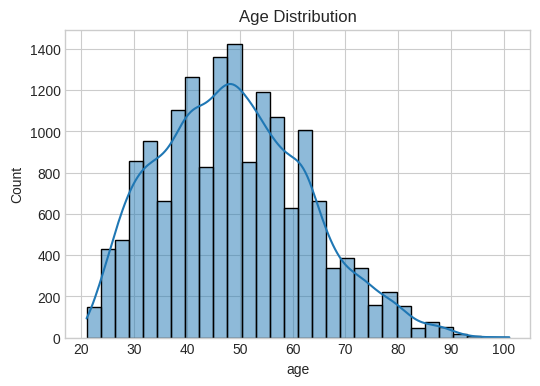

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

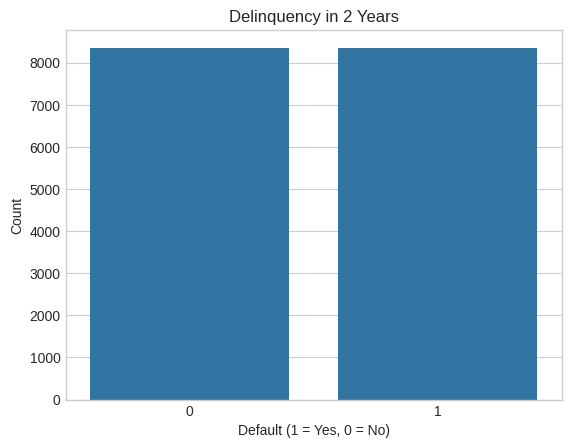

In [21]:
sns.countplot(x='dlq_2yrs', data=df)
plt.title("Delinquency in 2 Years")
plt.xlabel("Default (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

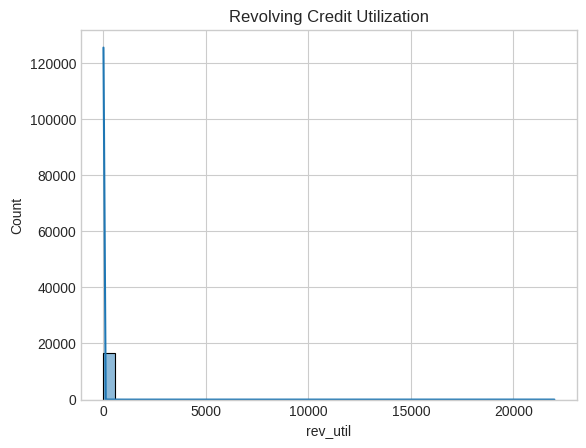

In [22]:
sns.histplot(df['rev_util'], bins=40, kde=True)
plt.title("Revolving Credit Utilization")
plt.show()

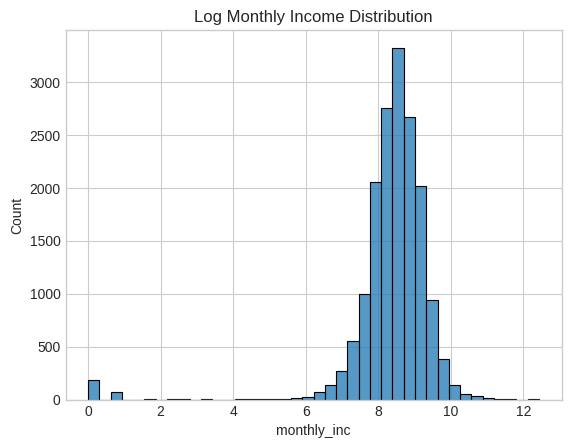

In [23]:
sns.histplot(np.log1p(df['monthly_inc']), bins=40)
plt.title("Log Monthly Income Distribution")
plt.show()

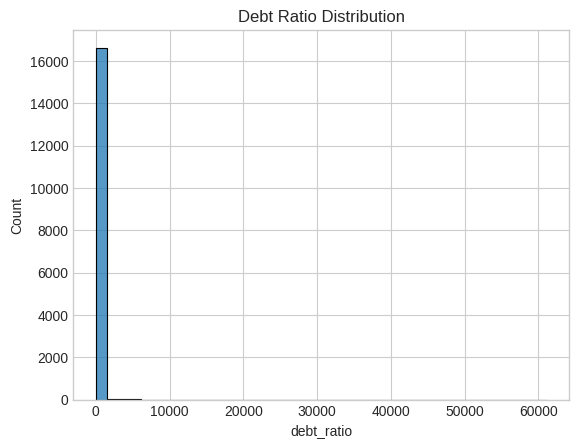

In [24]:
sns.histplot(df['debt_ratio'], bins=40)
plt.title("Debt Ratio Distribution")
plt.show()

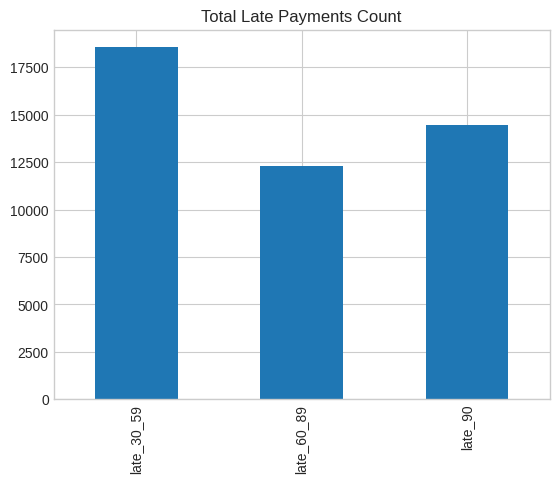

In [25]:
late_cols = ['late_30_59','late_60_89','late_90']

df[late_cols].sum().plot(kind='bar')
plt.title("Total Late Payments Count")
plt.show()

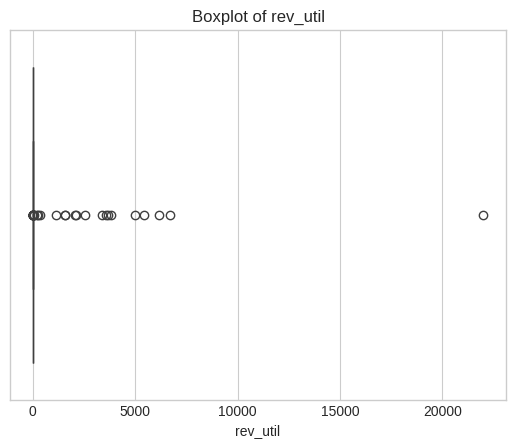

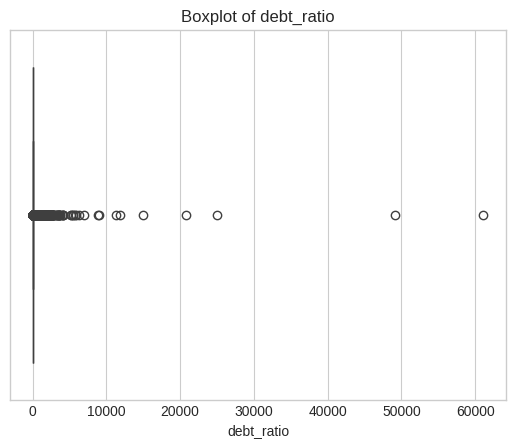

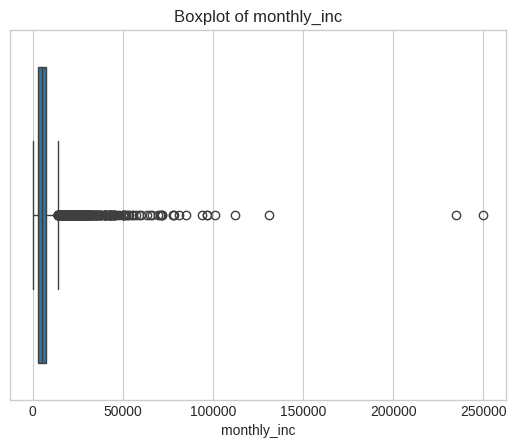

In [26]:
for col in ['rev_util','debt_ratio','monthly_inc']:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

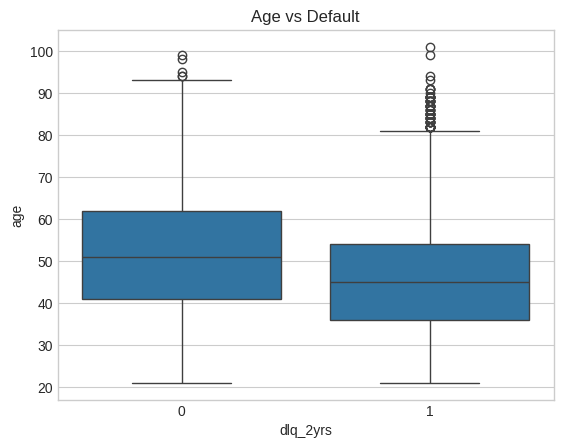

In [27]:
sns.boxplot(x='dlq_2yrs', y='age', data=df)
plt.title("Age vs Default")
plt.show()

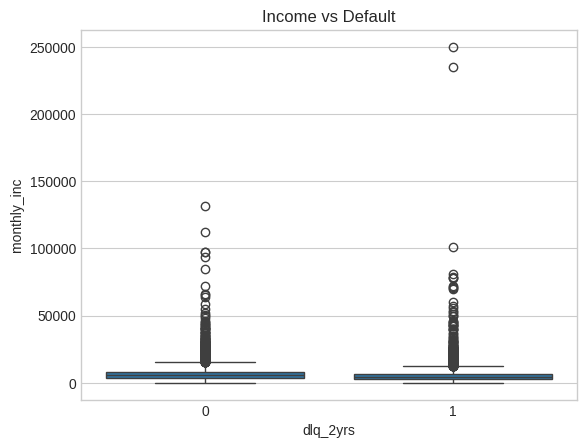

In [28]:
sns.boxplot(x='dlq_2yrs', y='monthly_inc', data=df)
plt.title("Income vs Default")
plt.show()

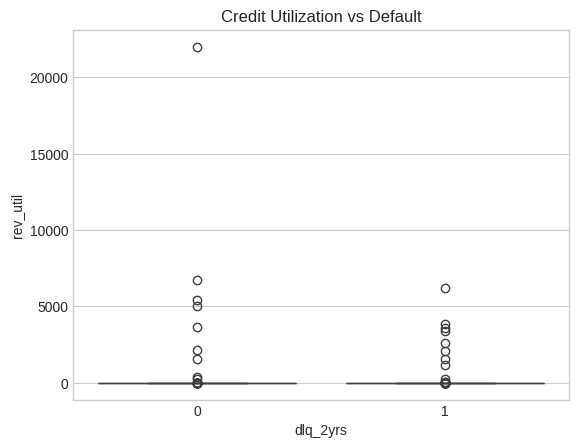

In [29]:
sns.boxplot(x='dlq_2yrs', y='rev_util', data=df)
plt.title("Credit Utilization vs Default")
plt.show()

Cloning into 'CreditCompass'...
fatal: unable to access 'https://github.com/Arohi-jd/CreditCompass/': Could not resolve host: github.com
